In [18]:
from langgraph.graph import StateGraph,START,END
import os
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from dotenv import load_dotenv
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import TypedDict,List,Literal
from langchain_community.vectorstores import FAISS
from pydantic import BaseModel,Field
from langchain_openai import ChatOpenAI,OpenAIEmbeddings


In [3]:
load_dotenv()

True

In [4]:
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
llm = ChatOpenAI(
    model="nvidia/nemotron-3-super-120b-a12b:free",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
)

In [5]:
docs=(
    PyPDFLoader("./Documents/Company_Policies.pdf").load()+
    PyPDFLoader("./Documents/Company_Profile.pdf").load()+
    PyPDFLoader("./Documents/Product_and_pricing.pdf").load()
)

In [6]:
chunks=RecursiveCharacterTextSplitter(chunk_size=600,chunk_overlap=150).split_documents(docs)

In [7]:
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)

In [8]:
vector_store=FAISS.from_documents(chunks,embeddings)

In [9]:
rtriever=vector_store.as_retriever(search_kwargs={"k":3})

In [ ]:
class State(TypedDict):
    question:str
    need_retrieval:bool

    docs:List[Document]
    answer:str

In [14]:
class RetrieveDecision(BaseModel):
    should_retrive:bool=Field(
        description="True if exteral documentds are needed to answer reliably,else false."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm=llm.with_structured_output(RetrieveDecision)

In [15]:
def decide(state:State):
    descision:RetrieveDecision=should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state['question'])
    )
    return {
        "need_retrieval":descision.should_retrive
    }

In [16]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def generate(state:State):
    out=llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer":out.content
    }

In [17]:
def retrieve(state:State):
    return {
        "docs":rtriever.invoke(state["question"])
    }

In [19]:
def route_after_decide(state:State)->Literal["Generate","Retrieve"]:
    if state["need_retrieval"]:
        return "Retrieve"
    return "Generate"

In [20]:
g=StateGraph(State)

g.add_node("Decide",decide)
g.add_node("Generate",generate)
g.add_node("Retrieve",retrieve)

g.add_edge(START,"Decide")
g.add_conditional_edges(
    "Decide",
    route_after_decide,
    {
        "Retrieve":"Retrieve",
        "Generate":"Generate"
    }
)

g.add_edge("Generate",END)
g.add_edge("Retrieve",END)

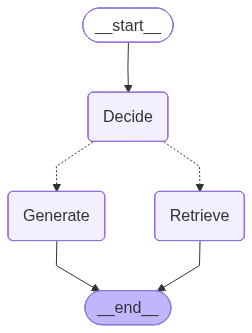

In [21]:
app=g.compile()
app

In [22]:
result = app.invoke(
    {
        "question": "What is Machine Learning",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

Machine Learning (ML) is a subset of artificial intelligence (AI) focused on building systems that **learn patterns from data** to make predictions or decisions without being explicitly programmed for each specific task. Instead of following rigid rules, ML algorithms identify statistical relationships in historical data and use those insights to generalize to new, unseen situations.

Key aspects include:
- **Data-driven**: Performance improves with more relevant data (e.g., training an email spam filter on thousands of labeled spam/not-spam examples).
- **Generalization**: The goal is to apply learned patterns to new data (not just memorize training examples).
- **Main approaches**:
  - *Supervised Learning*: Learns from labeled data (input → known output), e.g., predicting house prices from features like size and location.
  - *Unsupervised Learning*: Finds hidden patterns in unlabeled data, e.g., grouping customers by purchasing behavior.
  - *Reinforcement Learning*: Learns via tri

In [26]:
result['need_retrieval']

False